In [1]:
# ============================================================
# NOTEBOOK 2: Teacher Network Training + Pseudo-Label Generation
# Runtime: TPU (recommended) or GPU
# 
# Inputs required (add as Kaggle dataset inputs):
#   1. Your bladder tissue dataset (images)
#   2. Your splits dataset (nb2_teacher_train/val/test CSVs)
#
# Outputs:
#   teacher_best.weights.h5          -> used by Notebook 3
#   nbi_pseudo_labels.csv    -> used by Notebook 3
#   teacher_training_log.csv
#   teacher_confusion_matrix.png
#   teacher_training_curves.png
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet101
from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# CONFIG
# ============================================================

class CFG:
    # --- Paths ---
    DATASET_PATH = "/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue"
    ROOT_PATH = "/kaggle/input/datasets/kathan1803/ebt-research-processed-data"
    OUTPUT_PATH = "/kaggle/working/"

    # --- Hyperparameters ---
    IMG_SIZE     = 224        # ResNet101 standard input size
    BATCH_SIZE   = 32        
    EPOCHS_P1    = 20         # Phase 1: train head only (frozen backbone)
    EPOCHS_P2    = 50         # Phase 2: fine-tune top layers
    LR_P1        = 1e-4       # Phase 1 learning rate
    LR_P2        = 1e-5       # Phase 2 LR (paper: 1e-5 for classifier)

    # --- Dataset ---
    CLASS_NAMES  = ['HGC', 'LGC', 'NST', 'NTL']
    NUM_CLASSES  = 4
    TISSUE_COL   = 'tissue type'
    DOMAIN_COL   = 'imaging type'
    PATH_COL     = 'full_path'

    AUTOTUNE     = tf.data.AUTOTUNE

os.makedirs(CFG.OUTPUT_PATH, exist_ok=True)

2026-02-24 10:05:05.308198: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771927505.330281     234 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771927505.337191     234 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771927505.354336     234 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771927505.354359     234 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771927505.354362     234 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================================
# TPU / GPU SETUP
# ============================================================

import tensorflow as tf

def setup_strategy():

    # -------- TPU --------
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        print("Running on TPU")
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        return strategy, 'tpu'

    except ValueError:
        pass  # No TPU available

    # -------- GPU --------
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"Running on {len(gpus)} GPU(s)")
        strategy = tf.distribute.MirroredStrategy()
        return strategy, 'gpu'

    # -------- CPU --------
    print("Running on CPU")
    return tf.distribute.get_strategy(), 'cpu'


strategy, device_type = setup_strategy()
print("Replicas:", strategy.num_replicas_in_sync)

GLOBAL_BATCH = CFG.BATCH_SIZE * strategy.num_replicas_in_sync
print(f"Global batch size: {GLOBAL_BATCH}")

Running on 1 GPU(s)
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Replicas: 1
Global batch size: 32


I0000 00:00:1771927514.476766     234 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
# ============================================================
# LOAD SPLIT CSVs
# ============================================================

def filter_existing(df, base_path, path_col='full_path'):
    """Filter rows where the constructed absolute path actually exists."""
    def exists(p):
        full = os.path.join(base_path, p.strip())
        return os.path.exists(full)
    
    mask = df[path_col].apply(exists)
    missing = (~mask).sum()
    if missing:
        print(f"  Dropping {missing} rows with missing files")
    return df[mask].reset_index(drop=True)

train_df = pd.read_csv(os.path.join(CFG.ROOT_PATH, "nb2_teacher_train.csv"))
val_df   = pd.read_csv(os.path.join(CFG.ROOT_PATH, "nb2_teacher_val.csv"))
test_df  = pd.read_csv(os.path.join(CFG.ROOT_PATH, "nb2_teacher_test.csv"))
nbi_df   = pd.read_csv(os.path.join(CFG.ROOT_PATH, "nb3_student_train_nbi.csv"))

# Filter and build absolute paths
train_df = filter_existing(train_df, CFG.DATASET_PATH)
val_df   = filter_existing(val_df,   CFG.DATASET_PATH)
test_df  = filter_existing(test_df,  CFG.DATASET_PATH)
nbi_df   = filter_existing(nbi_df,   CFG.DATASET_PATH)

for df in [train_df, val_df, test_df, nbi_df]:
    df['full_path'] = df['full_path'].apply(
        lambda p: os.path.join(CFG.DATASET_PATH, p.strip())
    )

print(f"Teacher train : {len(train_df)} WLI images")
print(f"Teacher val   : {len(val_df)} WLI images")
print(f"Teacher test  : {len(test_df)} WLI images")
print(f"NBI unlabeled : {len(nbi_df)} NBI images")

print(f"\nSample path: {train_df['full_path'].iloc[0]}")

print(f"\nTrain class distribution:")
print(train_df[CFG.TISSUE_COL].value_counts().to_dict())
print(f"\nVal class distribution:")
print(val_df[CFG.TISSUE_COL].value_counts().to_dict())
print(f"\nTest class distribution:")
print(test_df[CFG.TISSUE_COL].value_counts().to_dict())

  Dropping 31 rows with missing files
  Dropping 6 rows with missing files
Teacher train : 912 WLI images
Teacher val   : 315 WLI images
Teacher test  : 131 WLI images
NBI unlabeled : 243 NBI images

Sample path: /kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue/NTL/case_022_pt_003_frame_0000.png

Train class distribution:
{'LGC': 320, 'HGC': 299, 'NST': 228, 'NTL': 65}

Val class distribution:
{'LGC': 112, 'HGC': 98, 'NST': 82, 'NTL': 23}

Test class distribution:
{'LGC': 70, 'NST': 44, 'NTL': 9, 'HGC': 8}


In [4]:
# ============================================================
# CLASS WEIGHTS
# Handle class imbalance — critical for NTL which has very few samples
# ============================================================

train_labels_raw = [
    CFG.CLASS_NAMES.index(t) for t in train_df[CFG.TISSUE_COL]
]

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CFG.NUM_CLASSES),
    y=train_labels_raw
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("\nClass weights (inverse frequency):")
for i, cls in enumerate(CFG.CLASS_NAMES):
    n = train_df[train_df[CFG.TISSUE_COL] == cls].shape[0]
    print(f"  {cls}: {n} images -> weight = {class_weights_arr[i]:.4f}")


Class weights (inverse frequency):
  HGC: 299 images -> weight = 0.7625
  LGC: 320 images -> weight = 0.7125
  NST: 228 images -> weight = 1.0000
  NTL: 65 images -> weight = 3.5077


In [5]:
# ============================================================
# DATA PIPELINE
# ============================================================

def preprocess_image(path, label, augment=False):
    """
    Load, resize, preprocess for ResNet101.
    Augmentation for training: random crop, rotation, flip
    (matches paper Section III-C augmentation description).
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [CFG.IMG_SIZE, CFG.IMG_SIZE])
    img = tf.cast(img, tf.float32)

    if augment:
        # Random crop: resize to slightly larger then crop back
        img = tf.image.resize(img, [int(CFG.IMG_SIZE * 1.1),
                                     int(CFG.IMG_SIZE * 1.1)])
        img = tf.image.random_crop(img, [CFG.IMG_SIZE, CFG.IMG_SIZE, 3])
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        # Random rotation via contrib or manual (using map_fn approach)
        img = tf.image.rot90(
            img, k=tf.random.uniform(shape=[], minval=0, maxval=4,
                                     dtype=tf.int32)
        )
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)

    img.set_shape([CFG.IMG_SIZE, CFG.IMG_SIZE, 3])

    # ResNet101 preprocessing: converts [0,255] to ImageNet-normalized
    img = tf.keras.applications.resnet.preprocess_input(img)

    label_oh = tf.one_hot(label, CFG.NUM_CLASSES)
    return img, label_oh


def make_dataset(df, augment=False, training=False):
    paths  = df[CFG.PATH_COL].tolist()
    labels = [CFG.CLASS_NAMES.index(t) for t in df[CFG.TISSUE_COL]]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, l: preprocess_image(p, l, augment=augment),
        num_parallel_calls=CFG.AUTOTUNE
    )
    ds = ds.batch(GLOBAL_BATCH, drop_remainder=False)
    ds = ds.prefetch(CFG.AUTOTUNE)
    return ds


def make_inference_dataset(df):
    """Dataset for inference — no labels, no augmentation."""
    paths = df[CFG.PATH_COL].tolist()
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(
        lambda p: preprocess_inference(p),
        num_parallel_calls=CFG.AUTOTUNE
    )
    ds = ds.batch(GLOBAL_BATCH, drop_remainder=False)
    ds = ds.prefetch(CFG.AUTOTUNE)
    return ds


def preprocess_inference(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [CFG.IMG_SIZE, CFG.IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img.set_shape([CFG.IMG_SIZE, CFG.IMG_SIZE, 3])
    img = tf.keras.applications.resnet.preprocess_input(img)
    return img


train_ds = make_dataset(train_df, augment=True,  training=True)
val_ds   = make_dataset(val_df,   augment=False, training=False)
test_ds  = make_dataset(test_df,  augment=False, training=False)

print(f"\nDatasets built:")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val batches   : {len(val_ds)}")
print(f"  Test batches  : {len(test_ds)}")


Datasets built:
  Train batches : 29
  Val batches   : 10
  Test batches  : 5


In [6]:
# ============================================================
# MODEL: ResNet101 Teacher Network
# ResNet-101 trained on ImageNet as backbone
# Classifier head: GlobalAveragePooling -> FC layers -> softmax
# ============================================================

def build_teacher(num_classes=4, trainable_base=False):
    """
    ResNet101 + classification head.
    trainable_base=False for Phase 1 (head only)
    trainable_base=True  for Phase 2 (fine-tune top layers)
    """
    base = ResNet101(
        include_top=False,
        weights='imagenet',
        input_shape=(CFG.IMG_SIZE, CFG.IMG_SIZE, 3)
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(CFG.IMG_SIZE, CFG.IMG_SIZE, 3))
    x = base(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    # Paper uses FC layers before final classification
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="teacher_resnet101")
    return model, base

In [7]:
# ============================================================
# METRICS
# Accuracy, Precision, Recall, F1, MCC, Cohen's Kappa
# ============================================================

def get_metrics():
    return [
        keras.metrics.CategoricalAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]

In [8]:
# ============================================================
# TRAINING PHASE 1: Frozen backbone, train head only
# ============================================================

print("\n" + "="*55)
print("PHASE 1: Training classifier head (backbone frozen)")
print("="*55)

with strategy.scope():
    teacher_model, base_resnet = build_teacher(
        num_classes=CFG.NUM_CLASSES,
        trainable_base=False
    )
    teacher_model.compile(
        optimizer=keras.optimizers.Adam(CFG.LR_P1),
        loss='categorical_crossentropy',
        metrics=get_metrics()
    )

print(f"Total params    : {teacher_model.count_params():,}")
print(f"Trainable params: {sum([tf.size(v).numpy() for v in teacher_model.trainable_variables]):,}")

callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CFG.OUTPUT_PATH, "teacher_phase1_best.weights.h5"),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        os.path.join(CFG.OUTPUT_PATH, "teacher_phase1_log.csv")
    ),
]

history_p1 = teacher_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.EPOCHS_P1,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1,
    verbose=1,
)

print(f"\nPhase 1 complete.")
print(f"Best val accuracy: {max(history_p1.history['val_accuracy']):.4f}")


PHASE 1: Training classifier head (backbone frozen)
Total params    : 43,709,316
Trainable params: 1,051,140
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0

I0000 00:00:1771927536.187934     291 cuda_dnn.cc:529] Loaded cuDNN version 91002


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.3524 - loss: 2.0193 - precision: 0.3766 - recall: 0.2785
Epoch 1: val_accuracy improved from -inf to 0.71111, saving model to /kaggle/working/teacher_phase1_best.weights.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.3537 - loss: 2.0085 - precision: 0.3779 - recall: 0.2794 - val_accuracy: 0.7111 - val_loss: 0.7959 - val_precision: 0.8209 - val_recall: 0.5238 - learning_rate: 1.0000e-04
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5570 - loss: 1.1688 - precision: 0.6049 - recall: 0.4774
Epoch 2: val_accuracy did not improve from 0.71111
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.5573 - loss: 1.1690 - precision: 0.6050 - recall: 0.4774 - val_accuracy: 0.6889 - val_loss: 0.7346 - val_precision: 0.8051 - val_recall: 0.6032 - learning_rate: 1.0000e-04
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6216 - loss: 0.9700 - precision: 0.6646 - recall: 0.5467
Epoch 3: val_accurac

In [9]:
# ============================================================
# TRAINING PHASE 2: Unfreeze top portion of ResNet, fine-tune
# Fine-tuning of ResNet101 on WLI images
# ============================================================

print("\n" + "="*55)
print("PHASE 2: Fine-tuning ResNet101 (top layers unfrozen)")
print("="*55)

# Unfreeze top 40% of ResNet layers
# Keep early layers frozen (they contain generic ImageNet features)
# Unfreeze later layers (they learn task-specific features)
total_layers   = len(base_resnet.layers)
freeze_until   = int(total_layers * 0.6)   # freeze first 60%

with strategy.scope():
    for i, layer in enumerate(base_resnet.layers):
        layer.trainable = (i >= freeze_until)

    frozen_count   = sum(1 for l in base_resnet.layers if not l.trainable)
    trainable_count = sum(1 for l in base_resnet.layers if l.trainable)
    print(f"ResNet layers   : {total_layers} total")
    print(f"Frozen          : {frozen_count}")
    print(f"Trainable       : {trainable_count}")

    # Recompile with lower LR for fine-tuning
    teacher_model.compile(
        optimizer=keras.optimizers.Adam(CFG.LR_P2),
        loss='categorical_crossentropy',
        metrics=get_metrics()
    )

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CFG.OUTPUT_PATH, "teacher_best.weights.h5"),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-9,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        os.path.join(CFG.OUTPUT_PATH, "teacher_phase2_log.csv")
    ),
]

history_p2 = teacher_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.EPOCHS_P2,
    class_weight=class_weight_dict,
    callbacks=callbacks_p2,
    verbose=1,
)

# Save final weights regardless of best checkpoint
teacher_model.save_weights(
    os.path.join(CFG.OUTPUT_PATH, "teacher_final.weights.h5")
)

print(f"\nPhase 2 complete.")
print(f"Best val accuracy: {max(history_p2.history['val_accuracy']):.4f}")


PHASE 2: Fine-tuning ResNet101 (top layers unfrozen)
ResNet layers   : 345 total
Frozen          : 207
Trainable       : 138
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.7373 - loss: 0.7349 - precision: 0.7631 - recall: 0.6989
Epoch 1: val_accuracy improved from -inf to 0.88571, saving model to /kaggle/working/teacher_best.weights.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 536ms/step - accuracy: 0.7380 - loss: 0.7323 - precision: 0.7640 - recall: 0.6997 - val_accuracy: 0.8857 - val_loss: 0.3106 - val_precision: 0.8987 - val_recall: 0.8730 - learning_rate: 1.0000e-05
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8092 - loss: 0.4968 - precision: 0.8404 - recall: 0.7850
Epoch 2: val_accuracy improved from 0.88571 to 0.89206, saving model to /kaggle/working/teacher_best.weights.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 386ms/step - accuracy: 0.8096 - loss: 0.4947 - precision: 0.8407 - recall: 0.7852 - val_accuracy: 0.8921 - val_loss: 0.3043 - val_precision: 0.9052 

In [10]:
# ============================================================
# LOAD BEST WEIGHTS FOR EVALUATION
# ============================================================

teacher_model.load_weights(
    os.path.join(CFG.OUTPUT_PATH, "teacher_best.weights.h5")
)
print("\nLoaded best weights for evaluation.")


Loaded best weights for evaluation.



EVALUATION: Validation (WLI)
              precision    recall  f1-score   support

         HGC     1.0000    0.9082    0.9519        98
         LGC     0.9649    0.9821    0.9735       112
         NST     0.9419    0.9878    0.9643        82
         NTL     0.8846    1.0000    0.9388        23

    accuracy                         0.9619       315
   macro avg     0.9478    0.9695    0.9571       315
weighted avg     0.9640    0.9619    0.9618       315

Overall Accuracy  : 0.9619
Weighted Precision: 0.9640
Weighted Recall   : 0.9619
Weighted F1       : 0.9618
MCC               : 0.9468
Cohen's Kappa     : 0.9461


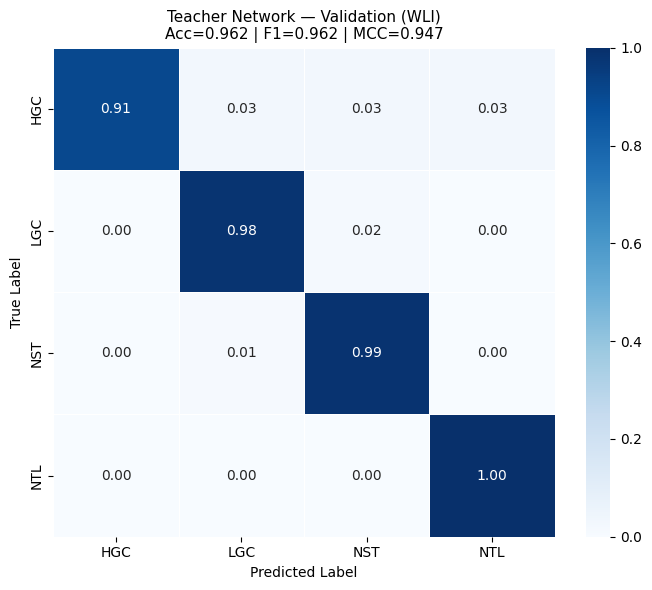


EVALUATION: Test (WLI)
              precision    recall  f1-score   support

         HGC     1.0000    0.5000    0.6667         8
         LGC     1.0000    0.8571    0.9231        70
         NST     0.8627    1.0000    0.9263        44
         NTL     0.3125    0.5556    0.4000         9

    accuracy                         0.8626       131
   macro avg     0.7938    0.7282    0.7290       131
weighted avg     0.9067    0.8626    0.8726       131

Overall Accuracy  : 0.8626
Weighted Precision: 0.9067
Weighted Recall   : 0.8626
Weighted F1       : 0.8726
MCC               : 0.7845
Cohen's Kappa     : 0.7763


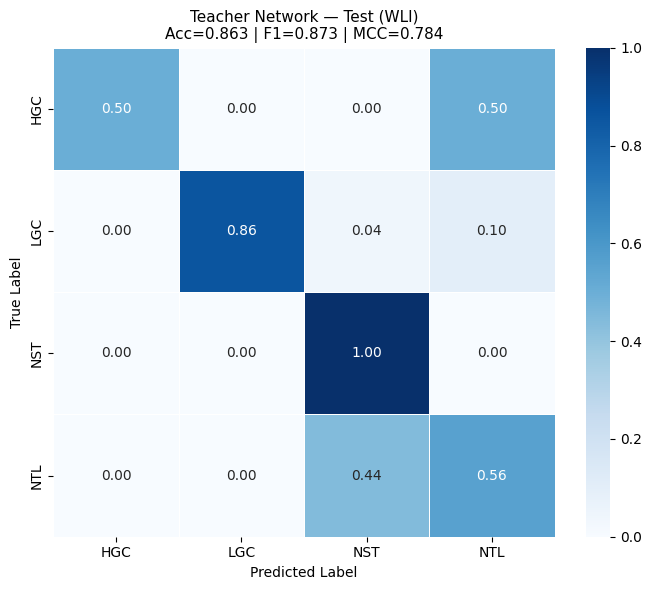

In [11]:
# ============================================================
# EVALUATION ON TEST SET
# Accuracy, Precision, Recall, F1, MCC, Cohen's Kappa
# ============================================================

def full_evaluation(model, dataset, df, class_names, split_name):
    """
    Run full evaluation matching paper's reported metrics:
    Accuracy, Precision, Recall, F1-score, MCC, Cohen's Kappa
    """
    y_true_all = []
    y_pred_all = []
    y_prob_all = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true_all.extend(np.argmax(labels.numpy(), axis=1))
        y_pred_all.extend(np.argmax(probs, axis=1))
        y_prob_all.extend(probs)

    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)

    # Per-class and overall metrics
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    mcc    = matthews_corrcoef(y_true, y_pred)
    kappa  = cohen_kappa_score(y_true, y_pred)
    acc    = report['accuracy']
    prec   = report['weighted avg']['precision']
    rec    = report['weighted avg']['recall']
    f1     = report['weighted avg']['f1-score']

    print(f"\n{'='*55}")
    print(f"EVALUATION: {split_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names, digits=4))
    print(f"Overall Accuracy  : {acc:.4f}")
    print(f"Weighted Precision: {prec:.4f}")
    print(f"Weighted Recall   : {rec:.4f}")
    print(f"Weighted F1       : {f1:.4f}")
    print(f"MCC               : {mcc:.4f}")
    print(f"Cohen's Kappa     : {kappa:.4f}")

    # Confusion matrix (normalized, matches paper Fig. 6 format)
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax, linewidths=0.5,
        vmin=0, vmax=1
    )
    ax.set_title(f'Teacher Network — {split_name}\n'
                 f'Acc={acc:.3f} | F1={f1:.3f} | MCC={mcc:.3f}',
                 fontsize=11)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    fname = f"teacher_cm_{split_name.lower().replace(' ','_')}.png"
    plt.savefig(os.path.join(CFG.OUTPUT_PATH, fname), dpi=150,
                bbox_inches='tight')
    plt.show()

    return {
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1,
        'mcc':       mcc,
        'kappa':     kappa,
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_prob':    np.array(y_prob_all),
    }

# Evaluate on val and test
val_results  = full_evaluation(
    teacher_model, val_ds,  val_df,  CFG.CLASS_NAMES, "Validation (WLI)")
test_results = full_evaluation(
    teacher_model, test_ds, test_df, CFG.CLASS_NAMES, "Test (WLI)")

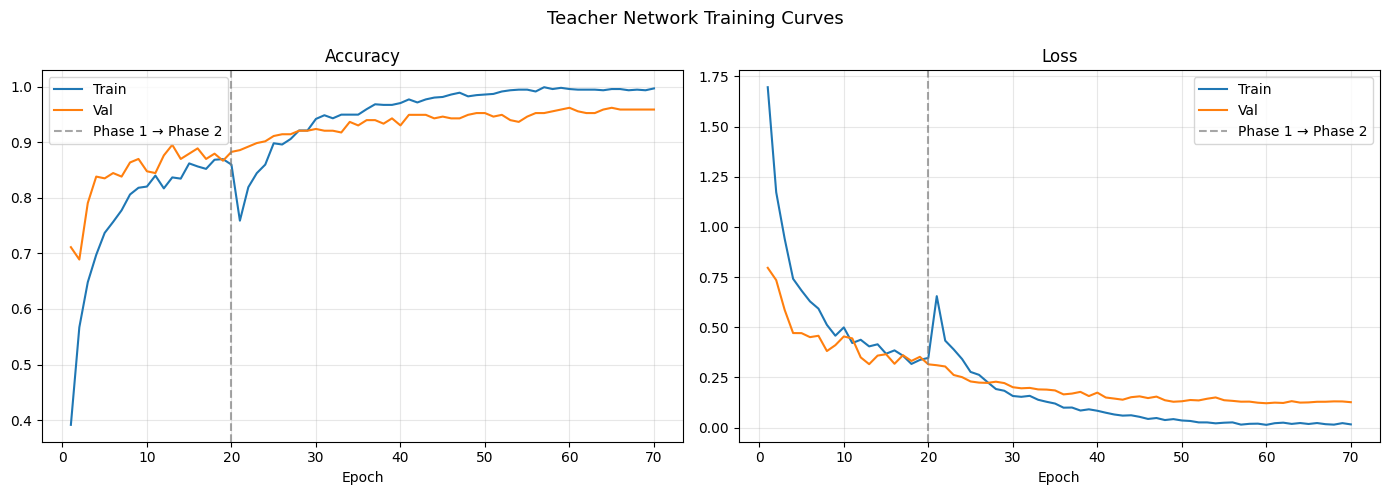

In [12]:
# ============================================================
# TRAINING CURVES
# ============================================================

def plot_training_curves(h1, h2, output_path):
    """Plot combined Phase 1 + Phase 2 training curves."""

    # Combine histories
    acc    = h1.history['accuracy']    + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss   = h1.history['loss']        + h2.history['loss']
    val_loss = h1.history['val_loss']  + h2.history['val_loss']
    p1_end = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Teacher Network Training Curves', fontsize=13)

    for ax, (train_vals, val_vals, title) in zip(axes, [
        (acc,  val_acc,  'Accuracy'),
        (loss, val_loss, 'Loss'),
    ]):
        epochs = range(1, len(train_vals) + 1)
        ax.plot(epochs, train_vals, label='Train')
        ax.plot(epochs, val_vals,   label='Val')
        ax.axvline(x=p1_end, color='gray', linestyle='--',
                   alpha=0.7, label='Phase 1 → Phase 2')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, "teacher_training_curves.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history_p1, history_p2, CFG.OUTPUT_PATH)


PSEUDO-LABEL GENERATION FOR NBI IMAGES
Generating pseudo-labels for 243 NBI images...

Pseudo-label distribution:
{'LGC': 118, 'NST': 62, 'HGC': 57, 'NTL': 6}

Confidence statistics:
  Mean   : 0.9008
  Median : 0.9779
  Min    : 0.3919
  Max    : 1.0000
  > 0.7  : 215 images (88.5%)
  > 0.5  : 238 images (97.9%)


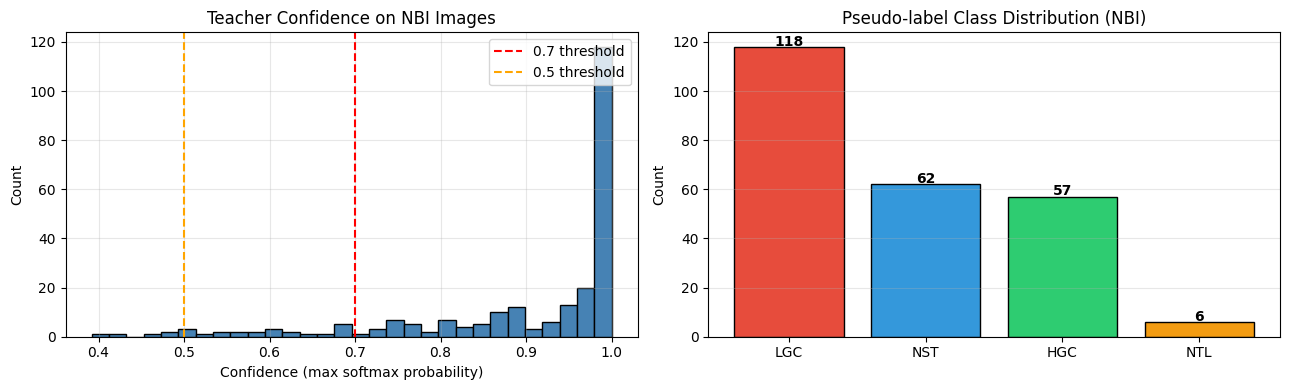

In [13]:
# ============================================================
# PSEUDO-LABEL GENERATION FOR NBI IMAGES
# Teacher predicts labels for unlabeled NBI training images.
# These pseudo-labels are used in Notebook 3 student training.
# ============================================================

print("\n" + "="*55)
print("PSEUDO-LABEL GENERATION FOR NBI IMAGES")
print("="*55)
print(f"Generating pseudo-labels for {len(nbi_df)} NBI images...")

nbi_inf_ds = make_inference_dataset(nbi_df)

all_probs = []
for batch in nbi_inf_ds:
    probs = teacher_model.predict(batch, verbose=0)
    all_probs.extend(probs)

all_probs  = np.array(all_probs)
all_preds  = np.argmax(all_probs, axis=1)
confidence = np.max(all_probs, axis=1)

# Build pseudo-label dataframe — preserves all original columns
# so Notebook 3 can use full_path, tissue type etc. directly
pseudo_df = nbi_df.copy()
pseudo_df['pseudo_label']      = all_preds
pseudo_df['pseudo_label_name'] = [CFG.CLASS_NAMES[p] for p in all_preds]
pseudo_df['confidence']        = confidence

# Add per-class probabilities (useful for confidence thresholding in NB3)
for i, cls in enumerate(CFG.CLASS_NAMES):
    pseudo_df[f'prob_{cls}'] = all_probs[:, i]

pseudo_df.to_csv(
    os.path.join(CFG.OUTPUT_PATH, "nbi_pseudo_labels.csv"),
    index=False
)

print(f"\nPseudo-label distribution:")
print(pseudo_df['pseudo_label_name'].value_counts().to_dict())
print(f"\nConfidence statistics:")
print(f"  Mean   : {confidence.mean():.4f}")
print(f"  Median : {np.median(confidence):.4f}")
print(f"  Min    : {confidence.min():.4f}")
print(f"  Max    : {confidence.max():.4f}")
print(f"  > 0.7  : {(confidence > 0.7).sum()} images "
      f"({100*(confidence>0.7).mean():.1f}%)")
print(f"  > 0.5  : {(confidence > 0.5).sum()} images "
      f"({100*(confidence>0.5).mean():.1f}%)")

# Confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(confidence, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(x=0.7, color='red', linestyle='--', label='0.7 threshold')
axes[0].axvline(x=0.5, color='orange', linestyle='--', label='0.5 threshold')
axes[0].set_title('Teacher Confidence on NBI Images')
axes[0].set_xlabel('Confidence (max softmax probability)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cls_counts = pseudo_df['pseudo_label_name'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
axes[1].bar(cls_counts.index, cls_counts.values,
            color=colors[:len(cls_counts)], edgecolor='black')
axes[1].set_title('Pseudo-label Class Distribution (NBI)')
axes[1].set_ylabel('Count')
for i, (cls, cnt) in enumerate(cls_counts.items()):
    axes[1].text(i, cnt + 0.5, str(cnt), ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_PATH, "pseudo_label_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# SAVE SUMMARY
# ============================================================

summary = {
    'val_accuracy':   float(val_results['accuracy']),
    'val_precision':  float(val_results['precision']),
    'val_recall':     float(val_results['recall']),
    'val_f1':         float(val_results['f1']),
    'val_mcc':        float(val_results['mcc']),
    'val_kappa':      float(val_results['kappa']),
    'test_accuracy':  float(test_results['accuracy']),
    'test_precision': float(test_results['precision']),
    'test_recall':    float(test_results['recall']),
    'test_f1':        float(test_results['f1']),
    'test_mcc':       float(test_results['mcc']),
    'test_kappa':     float(test_results['kappa']),
    'n_nbi_pseudo_labeled': len(pseudo_df),
    'pseudo_label_mean_confidence': float(confidence.mean()),
}

import json
with open(os.path.join(CFG.OUTPUT_PATH, "teacher_summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*55)
print("NOTEBOOK 2 COMPLETE")
print("="*55)
print(f"\nFiles saved to {CFG.OUTPUT_PATH}:")
print("  teacher_best.weights.h5              -> load in Notebook 3")
print("  teacher_final.weights.h5             -> backup")
print("  nbi_pseudo_labels.csv        -> load in Notebook 3")
print("  teacher_training_curves.png")
print("  teacher_cm_validation.png")
print("  teacher_cm_test_wli.png")
print("  teacher_summary.json")
print(f"\nKey results:")
print(f"  Test Accuracy  : {test_results['accuracy']:.4f}")
print(f"  Test F1        : {test_results['f1']:.4f}")
print(f"  Test MCC       : {test_results['mcc']:.4f}")
print(f"  Test Kappa     : {test_results['kappa']:.4f}")


NOTEBOOK 2 COMPLETE

Files saved to /kaggle/working/:
  teacher_best.weights.h5              -> load in Notebook 3
  teacher_final.weights.h5             -> backup
  nbi_pseudo_labels.csv        -> load in Notebook 3
  teacher_training_curves.png
  teacher_cm_validation.png
  teacher_cm_test_wli.png
  teacher_summary.json

Key results:
  Test Accuracy  : 0.8626
  Test F1        : 0.8726
  Test MCC       : 0.7845
  Test Kappa     : 0.7763
